In [1]:
# imports
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
# Introduction: File and Data Organisation

# File paths
TRAIN = '/kaggle/input/titanic/train.csv'
TEST = '/kaggle/input/titanic/test.csv'

df = pd.read_csv(TRAIN)
t_df = pd.read_csv(TEST)

# 🧹 Pre-processing stage  🧼:
The outline of our process and distribution of the next following cells is going to be the following to clearly outline how we will proceed:
1. Summarise visually and numerically numeric and str columns seperately
2. Feature Engineering a new ticket feature and then processing the ticket ID 
3. Binning Age, Sibsp and Parch, Fare, Ticket ID
4. Imputing Cabin column to remain an informative potentially more specific feautre than ticket
5. Label encode all categorical columns and binned columns and make final pre-processing adjustments

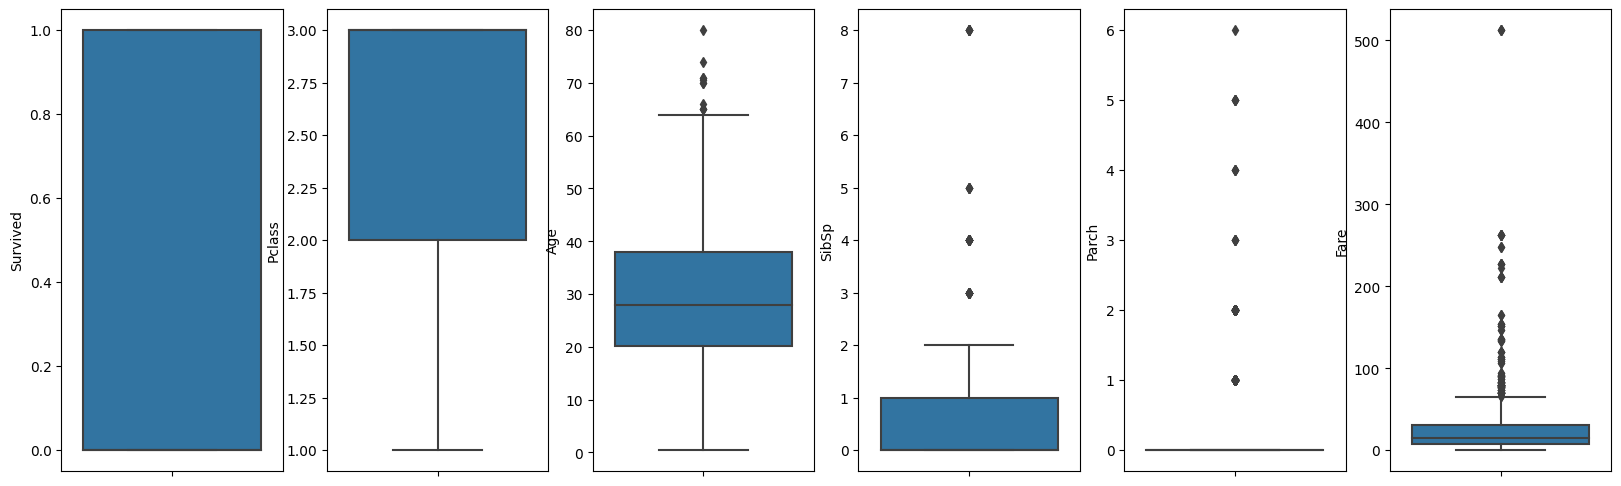

In [3]:
# Pre-processing Stage 1: Summarising and Commenting on Numeric and Object Columns 

# First seperate those columns
numeric_cols = df.select_dtypes(exclude=object)
str_cols = df.select_dtypes(include=object)

# Drop the passengerid
numeric_cols = numeric_cols.drop(columns='PassengerId')

# Numerics Section
numeric_cols.describe().T

# Graphical View
# numeric_cols.hist(figsize=(14,10))

# Objects Section
# str_cols.describe()

# Boxplot view - Outliers - plotting per column to prevent axis sharing\
fig, axes = plt.subplots(1, len(numeric_cols.columns), sharex=False, sharey=False, 
                        figsize=(20,6))

for i, col in enumerate(numeric_cols.columns):
    sns.boxplot(y=numeric_cols[col], ax=axes[i])

    

## Observations from Stage 1:
Note that while we split the data before stage 1 it is **generally safe to look at the entire dataset without any statistical pre-processing** - so that is why we are using the df frame here and not X_train or X_val.

By taking a very basic look using a print call for each seperated category based on type we can make some easy evaluations which should be fixed:

## Numeric Columns 

1. The 'PassengerID' column is something we can probably leave for now as it shouldn't be changed
2. Passenger class should remain quite informative being right skewed where most passengers are in class 3 (the lowest class - like economy class) - **will test without feature engineering**
3. Age seems decently spread but we can observe that the mean is 29 and approximately normal so slighter younger passengers - should also be a useful feature - **considering processing into age bins based on distribution**
4. SibSp and Parch seem to be less indicative features generally with most values being 0, however, intuitevly SibSp or Parch being 1+ potentially indicates wealth and **can be placed into bins for a simple feature right now**
5. Fare is quite skewed but the outlier points will provide a useful depiction of class - it should be useful to **generalise the fare into bins** - (e.g. 100+, then a couple before that to differentiate smaller classes)


## Object Columns 
1. All names are unique - potentially could take last names to find family members in the test set as we should be able to almost guarentee that families should share a similar outcome - **Requires text processing**
2. In the sex column it can be seen that most passengers in this dataset were male so we can **leave it for now as a large potential split depending on the survival of each gender**
3. There seems to be a lot more information provided in the ticket column, simply we can divide the values into either leading characters or no leading characters. No leading characters can indicate often first class passengers where the lower the number the earlier the booking was made. Leading characters can mean different things PC tickets - often first class, A/4 or A/5 tickets were 3rd class or steerage, STON/O tickets were bookings at the Southampton office. All of this may help to inform our predictions  **Create new feature by removing leading characters if present - seperating into no leading and then further categories and use the actual ticket numbers to indicate when they booked into different bins (quantile)** 
4. There seem to be a high presence of missing values in the cabin column (potential for imputation here based on similar rows with ticket column)
5. Embarked may also be a generally useful feature to indicate wealth - no processing required

From this we can derive that a very basic first implementation of this model after cleaning should focus on maximising the predicitive capabilties of age, gender and then somehow aggregating features to approximate a wealth category. 

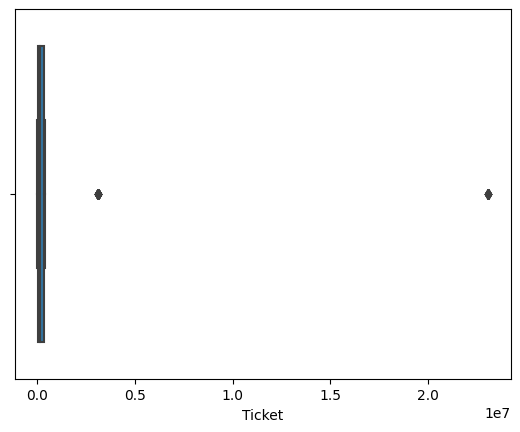

In [4]:
# Pre-processing Stage 2: Ticket Feature Engineering

leading_regex = r'([A-Za-z\./]+\d*)'
remove_regex = r'[A-Za-z\./]+\d*\s*'

# Create the new feature
df['Ticket_pre'] = df['Ticket'].str.extract(leading_regex)

# Remove it from the Ticket column 
df['Ticket'] = df['Ticket'].str.replace(remove_regex, '', regex=True)

# Relabel Null values
df['Ticket_pre'] = df['Ticket_pre'].fillna(value="NL") 
# NL - not labelled indicates potentially higher class

# Casefold 
df['Ticket_pre'] = df['Ticket_pre'].str.lower()

# Remove punctuation
df['Ticket_pre'] = df['Ticket_pre'].str.replace(r'\.', '', regex=True)

# Mark empty ticket values:
df['Ticket'].replace('', np.nan)

# Convert the column to int64
df['Ticket'] = pd.to_numeric(df['Ticket'], errors='coerce').astype('Int64')

# Plot to see distribute
sns.boxplot(x=df['Ticket'])

# Specifically enumerate outlier groups
outliers = df['Ticket'].loc[df['Ticket'] > 0.2*1e7]
outliers.loc[outliers > 2e7].min()

# Train organisation
target_col = 'Survived'
y = df[target_col]
X = df.drop(columns=target_col)

# Performing the splits:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Comments on stage 2: 
*Note we are still not using the splits here because the feature engineering is supossed to be applied to the entire dataset and not just specifically what will be used for the training phase. To reiterate, no statistical methods of pre-processing are used here so there should be no data leakage in this stage either.*

* Within the ticket naming system there are values within ranges 3e6 - 3.1e6 and then another group around ~2.3e7
* These likely represent an alternative ticketing system since according to google there are only around 1,300 passengers on the titanic
* Therefore, we might want to bin those two categories as they likely represent families or special groups traveling together and then take a quantile binning approach for the tickets within the majority of the distribution
* Since all steps that follow this in pre-processing could involve data leakage without proper handling, we choose to split the data set as the last step of stage 2

The following visual above supports this.

In [5]:
# Pre-processing stage 3: Binning

def quantile_binning(series, n_bins, is_ticket=False):
    """
    Converts a numeric column into bins based on the quantiles of that particular column
    """

    # Handle missing values:
    non_missing = series.notna()

    # Return indicative series if all values are missing 
    if not non_missing.any():
        return pd.Series("Missing", index=series.index, dtype='object')

    result = pd.Series('Missing', index=series.index, dtype='object')

    if is_ticket:
        # Handling based on digit length:
        ticket_str = series.astype(str)
        digit_len = ticket_str.str.len()

        # Creating artificial bins
        short_mask = digit_len <= 5 
        medium_mask = digit_len == 6
        long_mask = digit_len == 7
        very_long_mask = digit_len == 8
        
        # Applying masks:
        result.loc[short_mask & non_missing] = 'Short_Ticket'
        result.loc[medium_mask & non_missing] = 'Medium_Ticket'
        result.loc[long_mask & non_missing] = 'Long_Ticket'
        result.loc[very_long_mask & non_missing] = 'Very_long_Ticket'
        
    else:
        # Standard n bin case for Age, Fare, Parch, Sibsp, etc.
        try: 
            binned = pd.qcut(series, q=n_bins, duplicates='drop')
            result.loc[non_missing] = binned.astype(str)
        except:
            # In the case where there are not enough unique values for 5 quantiles 
            # fall back onto equal width bins
            binned = pd.cut(result, bins=n_bins)
            result.loc[non_missing] = binned.astype(str)

    return result

# Bin ages
X_train['Age_binned'] = quantile_binning(X_train['Age'], 5)
X_val['Age_binned'] = quantile_binning(X_val['Age'], 5)

# Bin SibSp, Parch, Fare and Ticket
X_train['SibSp_binned'] = quantile_binning(X_train['SibSp'], 4)
X_val['SibSp_binned'] = quantile_binning(X_val['SibSp'], 4)

X_train['Parch_binned'] = quantile_binning(X_train['Parch'], 4)
X_val['Parch_binned'] = quantile_binning(X_val['Parch'], 4)

X_train['Fare_binned'] = quantile_binning(X_train['Fare'], 5)
X_val['Fare_binned'] = quantile_binning(X_val['Fare'], 5)

X_train['Ticket_binned'] = quantile_binning(X_train['Ticket'], 4, is_ticket=True)
X_val['Ticket_binned'] = quantile_binning(X_val['Ticket'], 4, is_ticket=True)



## Comments on Stage 3:
1. Function incorporates ability to deal with missing values improving the robustness of the code
2. The ticket column is the only one treated differently here where we want to use the differences in length between various tickets to categorise the tickets -  this also allows us to incoporate our previous observation about the two outlier groups with large amounts of digits.
3. The Fare and Age columns are correctly binned into the passed in 5 bins based on their quantiles.
4. The SibSp ( # of siblings/ spouses) and Parch ( # of parents/ children) are passed in with 4 quantiles, however, we only recive two to correctly differentiate the outlier groups where most passengers just have 1 SibSp or Parch, and then the outlier groups can have 1-8.    

In [6]:
# Pre-processing Stage 5: Label encoding and final adjustments

from sklearn.preprocessing import OrdinalEncoder

# Selected features:
selected_features = ['Pclass', 'Sex', 'Age_binned', 'SibSp_binned', 'Parch_binned', 
                        'Ticket_binned', 'Fare_binned', 'Embarked', 'Ticket_pre']

# Convert all NaN to "Missing" to properly handle the following imputation
for col in selected_features:
    if X_train[col].isna().any():
        X_train[col] = X_train[col].fillna("Missing")
        X_val[col] = X_val[col].fillna("Missing")

# Handle any missing values using train median/mode
missing_label = "Missing"
for col in X_train.columns:
    if (X_train[col] == missing_label).any():
        # Only use data that doesn't include missing
        non_missing_train = X_train[col].loc[X_train[col] != "Missing"]

        # Find imputation value based on column type
        if X_train[col].dtype in ['float64', 'int64']:
            # Numerical case => Use median
            impute_value = non_missing_train.median()
        else:
            # Categorical case => Use mode
            mode_values = non_missing_train.mode()
            impute_value = mode_values[0] if len(mode_values) > 0  else 0

        # Apply imputation
        X_train[col] = X_train[col].replace(missing_label, impute_value)
        X_val[col] = X_val[col].replace(missing_label, impute_value)

# Create raw copies of dataset for readability in plots
X_train_raw = X_train[selected_features].copy()
X_val_raw = X_val[selected_features].copy()

# Create designated 
X_train_enc = X_train.copy()
X_val_enc = X_val.copy()
        
# Use ordinal encoder - one encoder for all columns  
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    
# Fit on training data
X_train_enc[selected_features] = encoder.fit_transform(X_train_enc[selected_features])

# Transform validation data
X_val_enc[selected_features] = encoder.transform(X_val_enc[selected_features])

 
for col in selected_features:
    if X_train_enc[col].isna().any():
        print(col)



## Comments on Stage 5:

* Only the desired features in selected feautres are encoded to be used in machine learning processes down the pipeline
* Values are imputed depending on their type, **numerical types - median** is used to ensure that values are central to the X_train dataset without being subject to the skew caused on the mean and for **categorical types - mode** is used because it is the most logical without the ability to perform mathematical operations
* The features are then encoded using the ordinal_encoder to correctly encode values without assuming an underlying numerical relationship for the numerical columns

# 🏹 Training and Execution Phase 💪: 
This now establishes the juicy more difficult stage of the data pipeline. Now allow me to outline the steps that should take place in this stage:

1. **Model Selection and Configuration**: Introduction of selected machine learning models and model parameter configuration based on basic data charactersitcs
2. **Level 1 - Initial Broad Screening**: Use of Gridsearch CV to find the optimum parameter set for all three models
3. **Level 2 - Detailed comparison of optimised models**: Models trained and evaluated on training data, including statistical insights, confusion matrices, ROC curves, classification reports, SHAP analysis, etc.
4. **Selection of Optimal Model with justification**: Selection of best model based on pre-determined success criteria with specific titanic relevance
5. **Kaggle Submission Generation**: Execute earlier phases with optimised model on all the data, create and save submission file for final execution 

In [7]:
# Model Selection and Configuration: 

def analyse_dataset(X_train, y_train):
    """
    Analayses key charactersticis of the dataset and returns a dictionary with such
    insights.
    """
    insights = {}

    # Basic Statistics:
    insights['n_samples'], insights['n_features'] = X_train.shape

    # Class distribution 
    target_classes = y_train.value_counts()
    insights['class_distribution'] = target_classes.to_dict()

    # Class imbalance: 1 yes, 0 no
    insights['is_imbalanced'] = (target_classes.max() / target_classes.sum()) > 0.7

    # Feature types: Numeric and non-Numeric
    insights['numeric_features'] = X_train.select_dtypes(include=[np.number]).columns.tolist()
    insights['categorical'] = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

    return insights


def get_logistic_params(insights):
    """
    Use insights from the dataset to derive a dictionary with tailored parameters for 
    a logistic regression model.

    Key parameters considered here are: 
    1. C: Inverse of regularisation strength - How much we trust our training data versus 
    how much we fear overfitting. Smaller C - lower risk of overfitting and vice versa. 

    2. Penalty: Adds a penalty term to the loss function preventing parameter terms from
    becoming too large and causing overfitting. We will just use l2.

    3. Solver: The algorithm used to find optimal weights used in the model

    4. Class_weight: Whether to adjust the weights of each feature to "balance" them out
    in case a class is underrepresented 

    5. Max_iter: Maximum number of steps the algorithm is allowed to take - because 
    iterative process like gradient descent is usually used. We will just use 1000.
    """
    
    parameters = {}

    # C parameter:
    if insights['n_features'] > 50:
        # Many features higher risk of overfitting
        parameters['C'] = [0.001, 0.01, 0.1]
    elif insights['n_features'] > 20:
        parameters['C'] = [0.01, 0.1, 1]
    else:
        parameters['C'] = [0.01, 0.1, 10]

    # Penalty:
    parameters['penalty'] = ['l2']

    # Solver:
    if insights['n_samples'] < 10000:
        # Pretty much mostly used - for smaller datasets
        parameters['solver'] = ['liblinear']
    else:
        parameters['solver'] = ['saga']

    # Class_weight:
    if insights['is_imbalanced']:
        parameters['class_weight'] = ['balanced']

    # Max_iterations 
    parameters['max_iter'] = [1000]

    return parameters

    
def get_rf_params(insights):
    """
    Use insights to derive best parameters for random forest. As before. 

    Specific parameters considered:
    
    1. n_estimators: number of trees - each tree sees a different subset of the data
    
    2. max_depth: How many splits is a tree allowed to make, the deeper the tree the higher
    the risk of overfitting but it can be useful for more complicated passenger patterns.
    
    3. min_samples_split: Minimum number of data points in a node in order for it to split.
    This helps avoid the tree splitting on too little people where their pattern might not
    be at all useful.

    4. min_samples_leaf: The minimum number of samples in order to create a leaf node. 

    5. bootstrap: Can use random sampling with replacement potentially improving the results
    by generalising the dataset. 

    6. class_weight: Similar to that it logistical regression. 

    7. max_features: Forces each tree to pick from a random subset of features to avoid one
    strong feature dominating 
    """
    parameters = {}

    # n_estimators:
    if insights['n_features'] > 30:
        parameters['n_estimators'] = [100, 200, 300]

    else:
        parameters['n_estimators'] = [50, 100, 150]

    # max_depth:
    if insights['n_samples'] < 100:
        parameters['max_depth'] = [3, 5] # shallow
    elif insights['n_samples'] < 1000:
        parameters['max_depth'] = [5, 10, 15] # medium depth
    else:
       parameters['max_depth'] = [10, 15, 20] # deep trees

    # minimum samples to split 
    if insights['n_samples'] < 200:
        parameters['min_samples_split'] = [5, 10] # Prevent overfitting
    else:
        parameters['min_samples_split'] = [2, 5, 10]

    # minimum samples per leaf
    if insights['n_samples'] < 200:
        parameters['min_samples_leaf'] = [3,5] # Larger leaves
    else:
        parameters['min_samples_leaf'] = [1, 2, 4] # Isn't this too little and likely to overfit

    # boostrap:
    parameters['bootstrap'] = [True, False]

    # Class imbalance
    if insights['is_imbalanced']:
        parameters['class_weight'] = ['balanced']
    else:
        parameters['class_weight'] = [None]

    # Feature sampling 
    parameters['max_features'] = ['sqrt', 'log2', None]

    return parameters
        
    
def get_xg_params(insights):
    """
    Get xg parameters based on data characteristics. 

    Specific parameters considered:
    
    1. n_estimators: determines the number of trees, similar concept to rf, but here this
    also means more boosting rounds 
    
    2. max_depth: determines the depth of each decision tree - very similar to rf. 

    3. learning_rate: determines how much each tree contributes to the final prediction, 
    however, lower rate => more trees => potentially more robust

    4. subsample: determines the fraction of data to be randomly samples for each boosting
    round. 

    5. colsampling: determines the fraction of features to be used when building each tree.

    6. eval_metric: the method used to determine how well the model is performing - we 
    will use logloss.

    7. reg_alpha and reg_lambda: add penalties to enforce regularisation

    8. scale_pos_weight: helps in imbalanced features to give more importance to minority
    classes
    """
    parameters = {}

    # Number of trees 
    parameters['n_estimators'] = [50, 100, 150]

    # Tree depth
    if insights['n_samples'] < 100:
        parameters['max_depth'] = [3, 4]
    elif insights['n_samples'] < 1000:
        parameters['max_depth'] = [4, 6, 8]
    else: 
        parameters['max_depth'] = [6, 8, 10]

    # Learning Rate 
    if insights['n_samples'] < 1000:
        parameters['learning_rate'] = [0.01, 0.05, 0.1]
    else:
        parameters['learning_rate'] = [0.1, 0.3]

    # Subsample ratio 
    parameters['subsample'] = [0.8, 0.9, 1]

    # Column sampling 
    parameters['colsample_bytree'] = [0.8, 0.9, 1]

    # Evaluation Metric 
    parameters['eval_metric'] = ['logloss']

    # Regularisation 
    if insights['n_features'] > 30:
        # Stronger regularisation for high dimensions 
        parameters['reg_alpha']  = [0, 0.1, 0.5]
        parameters['reg_lambda']  = [1, 1.5, 2]
    else:
        parameters['reg_alpha']  = [0, 0.01, 0.1]
        parameters['reg_lambda']  = [1, 1.25, 1.5]

    # Handles class imbalance
    if insights['is_imbalanced']:
        # Calculate the weight ratio 
        class_counts = list(insights['class_distribution'].values())
        scale_weight = class_counts[0] / class_counts[0] if len(class_counts) > 1 else 1
        parameters['scale_pos_weight'] = [scale_weight]
    else:
        parameters['scale_pos_weight'] = [1]

    return parameters

def det_cv_folds(insights):
    """
    Determine optimum number of CV folds based on data quantities.
    """
    n_samples = insights['n_samples']

    if n_samples < 100:
        return 3 
    else:
        return 10 if n_samples > 1000 else 5

def det_cv_scoring(insights):
    """
    Determine scoring metric to use in Cross Validation scoring based on distribution of 
    data.
    """
    if insights['is_imbalanced']:
        return 'roc_auc' # Better for cases with imbalanced data
    else:
        'accuracy'
    
insights = analyse_dataset(X_train, y_train)

config = {
    # Model Parameters
    'logistic': get_logistic_params(insights),
    'rf': get_rf_params(insights),
    'xgboost': get_xg_params(insights),

    # Other settings 
    'cv_folds': det_cv_folds(insights),
    'scoring_metric': det_cv_scoring(insights),
    'random_state': 42, 
    'test_size': 0.2  
}

# 🥽 Model Selection and Configuration 🎒
### Tailored code design
To clarify the above code I have chosen to implement a relatively tailored parameter selection for each Machine Learning model to achieve or select the best results based on the imputed dataset, and to not just achieve desired results for one dataset with certain charactersitics. Using the basic insights from the dataset we will adjust the machine learning model parameters to ensure the best parameters for the given dataset.

### Machine Learning Models
In the following example there will be three machine learning models that will be implemented alongside a justification:
1. Logitistical Regression:
2. Random Forest
3. XG Boost

Note the following considerations when considering the code above:
1. We are using reasonable estimate to categorise each parameter based on reasonable estimates and inuition about how the specific machine learning model will perform based on the adjustment of this parameter.
2. 

In [8]:
# Level 1: Initial Broad Screening 
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier 

def train_models(config):
    """
    Train all three models on the training data using the developed parameters from 
    before. 
    """

    # Derive parameters from previous stage
    cv_folds = config['cv_folds']
    random_state = config['random_state']
    scoring = config['scoring_metric']

    rf_params = config['rf']
    xg_params = config['xgboost']
    logistic_params = config['logistic']

    # Load in models
    rf = RandomForestClassifier(random_state=random_state)
    xgboost = XGBClassifier(random_state=random_state)
    logistic = LogisticRegression(random_state=random_state)

    # Grid searches for respective models
    grid_search_rf = GridSearchCV(
        estimator=rf, 
        param_grid=rf_params,
        cv=cv_folds,
        scoring=scoring,
        n_jobs=-1, # use all processors
        verbose=1 # Displays basic information if algorithm requires long computations
    )

    grid_search_xg = GridSearchCV(
        estimator=xgboost,
        param_grid=xg_params,
        cv=cv_folds,
        scoring=scoring,
        n_jobs=-1,
        verbose=1 
    )

    grid_search_log = GridSearchCV(
        estimator=logistic,
        param_grid=logistic_params,
        cv=cv_folds,
        scoring=scoring,
        n_jobs=-1,
        verbose=1 
    )

    # Fit models one after another
    grid_search_rf.fit(X_train_enc[selected_features], y_train)
    grid_search_xg.fit(X_train_enc[selected_features], y_train)
    grid_search_log.fit(X_train_enc[selected_features], y_train)

    # Get best models 
    best_rf = grid_search_rf.best_estimator_
    best_xg = grid_search_xg.best_estimator_
    best_log = grid_search_log.best_estimator_

    return best_rf, best_xg, best_log

best_rf, best_xg, best_log = train_models(config)




Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
